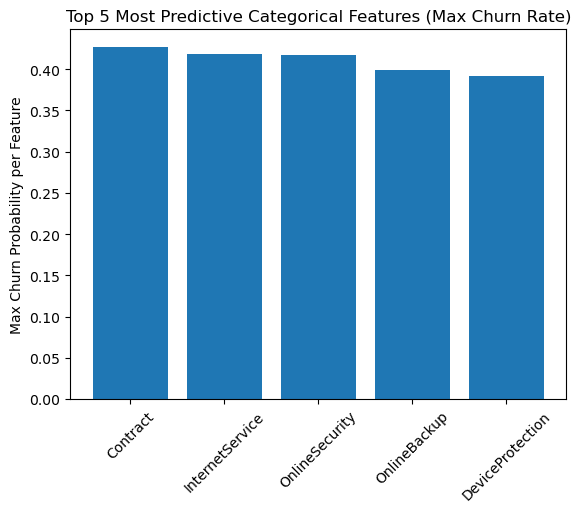

(0.2653698707936959,
 0.4270967741935484,
 0.4828419526341228,
 0.4189276485788114,
 0.4528541226215645,
 0.5460526315789473,
 2.057703950888457,
 'Two year',
 0.4168126094570928,
 0.23606168446026096,
 0.33565092304003835,
 0.1633008356545961,
 0.17235008738544225)

In [82]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('CustomerChurn.csv')

# Convert Churn to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert TotalCharges to numeric if needed
if df['TotalCharges'].dtype == 'object':
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 1. Overall churn probability
overall_churn = df['Churn'].mean()

# 2. Conditional probabilities
p_month_to_month = df[df['Contract'] == 'Month-to-month']['Churn'].mean()
p_tenure_lt_12 = df[df['tenure'] < 12]['Churn'].mean()
p_fiber = df[df['InternetService'] == 'Fiber optic']['Churn'].mean()
p_electronic_check = df[df['PaymentMethod'] == 'Electronic check']['Churn'].mean()

# 3. Joint probability & lift
p_joint = df[(df['Contract'] == 'Month-to-month') & 
             (df['InternetService'] == 'Fiber optic')]['Churn'].mean()

lift = p_joint / overall_churn

# 4. Feature comparisons
contract_churn = df.groupby('Contract')['Churn'].mean()
lowest_contract = contract_churn.idxmin()

senior_churn = df[df['SeniorCitizen'] == 1]['Churn'].mean()
non_senior_churn = df[df['SeniorCitizen'] == 0]['Churn'].mean()

paperless_yes = df[df['PaperlessBilling'] == 'Yes']['Churn'].mean()
paperless_no = df[df['PaperlessBilling'] == 'No']['Churn'].mean()
paperless_diff = paperless_yes - paperless_no

# 5. Find top 5 categorical features by absolute difference from overall churn
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'customerID']

feature_diffs = {}

for col in categorical_cols:
    rates = df.groupby(col)['Churn'].mean()
    max_diff = max(abs(rates - overall_churn))
    feature_diffs[col] = max_diff

# Select top 5 features
top5_features = sorted(feature_diffs, key=feature_diffs.get, reverse=True)[:5]

# For visualization: take max churn category per feature
visual_data = {}
for col in top5_features:
    rates = df.groupby(col)['Churn'].mean()
    visual_data[col] = rates.max()

# Create bar chart (single plot, no specific colors)
plt.figure()
plt.bar(visual_data.keys(), visual_data.values())
plt.xticks(rotation=45)
plt.ylabel("Max Churn Probability per Feature")
plt.title("Top 5 Most Predictive Categorical Features (Max Churn Rate)")
plt.show()

# Print results
overall_churn, p_month_to_month, p_tenure_lt_12, p_fiber, p_electronic_check, p_joint, lift, lowest_contract, senior_churn, non_senior_churn, paperless_yes, paperless_no, paperless_diff


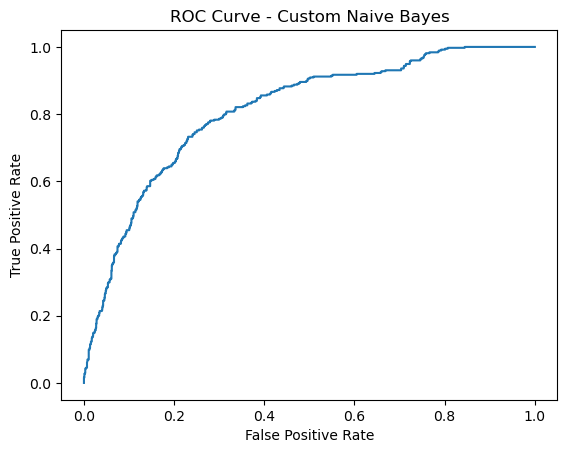

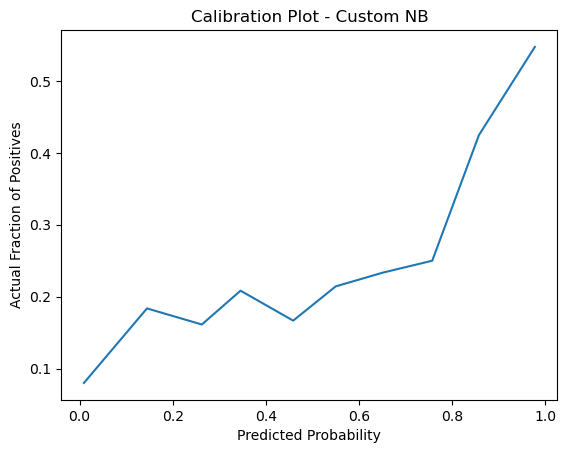

Custom Naive Bayes Results
Accuracy: 0.7182398864442867
Precision: 0.481421647819063
Recall: 0.7967914438502673
F1: 0.6002014098690835
Confusion Matrix:
 [[714 321]
 [ 76 298]]
AUC: 0.8103438476840011

sklearn GaussianNB Results
Accuracy: 0.6557842441447835
Precision: 0.4268774703557312
Recall: 0.8663101604278075
F1: 0.5719329214474845


In [88]:
# TASK 2: Naive Bayes From Scratch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.naive_bayes import GaussianNB

# Load dataset
df = pd.read_csv('CustomerChurn.csv')

# Convert target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values (replace with median)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Select numerical and categorical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'customerID']

# Train/Test split
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Compute Priors
prior_churn = y_train.mean()
prior_nochurn = 1 - prior_churn

# 2. Likelihood Estimation

# Numerical parameters (Gaussian)
num_params = {}

for col in numerical_cols:
    num_params[col] = {
        1: (X_train[y_train == 1][col].mean(),
            X_train[y_train == 1][col].std()),
        0: (X_train[y_train == 0][col].mean(),
            X_train[y_train == 0][col].std())
    }

# Categorical likelihoods with Laplace smoothing
cat_probs = {}

for col in categorical_cols:
    cat_probs[col] = {}
    values = X_train[col].unique()
    for c in [0,1]:
        total_c = len(X_train[y_train == c])
        probs = {}
        for v in values:
            count = len(X_train[(X_train[col] == v) & (y_train == c)])
            probs[v] = (count + 1) / (total_c + len(values))
        cat_probs[col][c] = probs

# Gaussian PDF
def gaussian_pdf(x, mean, std):
    if std == 0:
        return 1e-6
    exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
    return (1 / (np.sqrt(2 * np.pi) * std)) * exponent


# 3. Prediction

def predict_proba(row):
    prob_churn = prior_churn
    prob_nochurn = prior_nochurn
    
    # Numerical features
    for col in numerical_cols:
        mean1, std1 = num_params[col][1]
        mean0, std0 = num_params[col][0]
        
        prob_churn *= gaussian_pdf(row[col], mean1, std1)
        prob_nochurn *= gaussian_pdf(row[col], mean0, std0)
    
    # Categorical features
    for col in categorical_cols:
        val = row[col]
        prob_churn *= cat_probs[col][1].get(val, 1e-6)
        prob_nochurn *= cat_probs[col][0].get(val, 1e-6)
    
    total = prob_churn + prob_nochurn
    if total == 0:
        return 0.5
    return prob_churn / total

# Get predictions
probs = X_test.apply(predict_proba, axis=1)
y_pred = (probs > 0.5).astype(int)


# 4. Evaluation

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Custom Naive Bayes")
plt.show()

# Calibration Plot
bins = np.linspace(0,1,11)
digitized = np.digitize(probs, bins) - 1

calibration_points = []
for i in range(len(bins)-1):
    mask = digitized == i
    if mask.sum() > 0:
        avg_pred = probs[mask].mean()
        actual = y_test[mask].mean()
        calibration_points.append((avg_pred, actual))

if calibration_points:
    x_cal, y_cal = zip(*calibration_points)
    plt.figure()
    plt.plot(x_cal, y_cal)
    plt.xlabel("Predicted Probability")
    plt.ylabel("Actual Fraction of Positives")
    plt.title("Calibration Plot - Custom NB")
    plt.show()


# 5. sklearn GaussianNB Comparison

# Encode categorical features using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

gnb = GaussianNB()
gnb.fit(X_train_enc, y_train_enc)

y_pred_sklearn = gnb.predict(X_test_enc)
probs_sklearn = gnb.predict_proba(X_test_enc)[:,1]

acc_sklearn = accuracy_score(y_test_enc, y_pred_sklearn)
prec_sklearn = precision_score(y_test_enc, y_pred_sklearn)
rec_sklearn = recall_score(y_test_enc, y_pred_sklearn)
f1_sklearn = f1_score(y_test_enc, y_pred_sklearn)

# Print results
print("Custom Naive Bayes Results")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("Confusion Matrix:\n", cm)
print("AUC:", roc_auc)

print("\nsklearn GaussianNB Results")
print("Accuracy:", acc_sklearn)
print("Precision:", prec_sklearn)
print("Recall:", rec_sklearn)
print("F1:", f1_sklearn)


In [92]:
# Task 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Correct path for this environment
df = pd.read_csv('CustomerChurn.csv')

# Prepare data
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

model = GaussianNB()
model.fit(X_train, y_train)

df['P_Churn'] = model.predict_proba(X_encoded)[:,1]

# Scenario constants
CLV = 2000
cost = 300
success_rate = 0.4
budget = 50000

# 1. Maximum spend for P=0.8
max_spend_08 = 0.8 * CLV * success_rate

df['Expected_Value'] = df['P_Churn'] * CLV * success_rate - cost
target_all = df[df['P_Churn'] > 0.5]
expected_profit_all = target_all['Expected_Value'].sum()

# 2. Risk Segmentation
df['HighValue'] = df['MonthlyCharges'] > 70
df['HighRisk'] = df['P_Churn'] > 0.6

segments = {}
for hv in [True, False]:
    for hr in [True, False]:
        segment = df[(df['HighValue']==hv) & (df['HighRisk']==hr)]
        key = f"HV_{hv}_HR_{hr}"
        
        segments[key] = {
            "count": len(segment),
            "churn_loss": float((segment['P_Churn'] * CLV).sum()),
            "net_gain": float((segment['P_Churn'] * CLV * success_rate - cost).sum())
        }

roi_segment = max(segments, key=lambda k: segments[k]['net_gain'])

# 3. Budget Optimization
df_sorted = df.sort_values(by='Expected_Value', ascending=False)
df_positive = df_sorted[df_sorted['Expected_Value'] > 0]

max_customers = budget // cost
selected = df_positive.head(int(max_customers))

num_targeted = len(selected)
total_profit = float(selected['Expected_Value'].sum())

high_risk_total = len(df[df['HighRisk']==True])
high_risk_covered = len(selected[selected['HighRisk']==True])
high_risk_pct = high_risk_covered / high_risk_total if high_risk_total > 0 else 0

# 4. Sensitivity Analysis
def scenario_analysis(new_clv, new_cost, new_success):
    df_temp = df.copy()
    df_temp['EV'] = df_temp['P_Churn'] * new_clv * new_success - new_cost
    profitable = df_temp[df_temp['EV'] > 0]
    return len(profitable), float(profitable['EV'].sum())

scenarios = {
    "Success 20%": scenario_analysis(2000,300,0.2),
    "Cost 500": scenario_analysis(2000,500,0.4),
    "CLV 1500": scenario_analysis(1500,300,0.4)
}

print("1. Maximum Spend for P=0.8:", max_spend_08)
print("Expected Profit Targeting P>0.5:", expected_profit_all)

print("\n2. Segmentation Results")
for k,v in segments.items():
    print(k, v)

print("Best ROI Segment:", roi_segment)

print("\n3. Budget Optimization")
print("Customers Targeted:", num_targeted)
print("Total Expected Profit:", total_profit)
print("High Risk Coverage:", high_risk_pct)

print("\n4. Sensitivity Analysis")
for k,v in scenarios.items():
    print(k, "-> Customers Profitable:", v[0], "Total EV:", v[1])


1. Maximum Spend for P=0.8: 640.0
Expected Profit Targeting P>0.5: 1781235.976793226

2. Segmentation Results
HV_True_HR_True {'count': 2409, 'churn_loss': 4715164.599940913, 'net_gain': 1163365.8399763652}
HV_True_HR_False {'count': 1174, 'churn_loss': 159558.9111205784, 'net_gain': -288376.43555176863}
HV_False_HR_True {'count': 1291, 'churn_loss': 2486847.7231977824, 'net_gain': 607439.0892791131}
HV_False_HR_False {'count': 2169, 'churn_loss': 126799.35955764988, 'net_gain': -599980.25617694}
Best ROI Segment: HV_True_HR_True

3. Budget Optimization
Customers Targeted: 166
Total Expected Profit: 82999.82325089903
High Risk Coverage: 0.044864864864864865

4. Sensitivity Analysis
Success 20% -> Customers Profitable: 3582 Total EV: 333550.6024050033
Cost 500 -> Customers Profitable: 3682 Total EV: 1031003.6608506003
CLV 1500 -> Customers Profitable: 3772 Total EV: 1053026.9825949196
